In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_percentage_error,r2_score


In [2]:
url="https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"
df=pd.read_csv(url)

In [3]:
df.head()

,Month,Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Month       144 non-null    object
 1   Passengers  144 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 2.4+ KB


In [5]:
df["Month"]=pd.to_datetime(df["Month"])
df.set_index("Month",inplace=True)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 144 entries, 1949-01-01 to 1960-12-01
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Passengers  144 non-null    int64
dtypes: int64(1)
memory usage: 2.2 KB


In [7]:
df

,Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121
...,...
1960-08-01,606
1960-09-01,508
1960-10-01,461


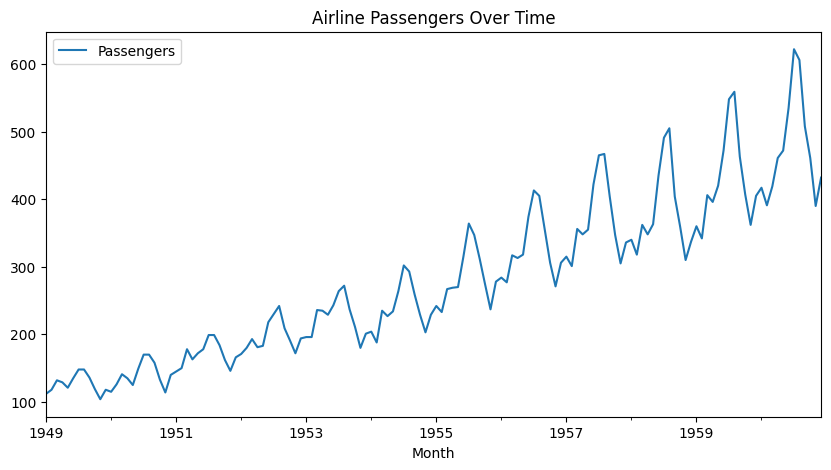

In [8]:
import matplotlib.pyplot as plt

df.plot(figsize=(10,5))
plt.title("Airline Passengers Over Time")
plt.show()

In [9]:
scaler=MinMaxScaler()
scale_val=scaler.fit_transform(df[["Passengers"]])

In [35]:
def create_sequences(data, time_steps):
    X, y = [], []
    for i in range(len(data) - time_steps):
        X.append(data[i:i+time_steps])
        y.append(data[i+time_steps])
    return np.array(X), np.array(y)

X, y = create_sequences(scale_val, 12)

In [36]:
X

array([[[0.01544402],
        [0.02702703],
        [0.05405405],
        ...,
        [0.02895753],
        [0.        ],
        [0.02702703]],

       [[0.02702703],
        [0.05405405],
        [0.04826255],
        ...,
        [0.        ],
        [0.02702703],
        [0.02123552]],

       [[0.05405405],
        [0.04826255],
        [0.03281853],
        ...,
        [0.02702703],
        [0.02123552],
        [0.04247104]],

       ...,

       [[0.58494208],
        [0.4980695 ],
        [0.58108108],
        ...,
        [1.        ],
        [0.96911197],
        [0.77992278]],

       [[0.4980695 ],
        [0.58108108],
        [0.6042471 ],
        ...,
        [0.96911197],
        [0.77992278],
        [0.68918919]],

       [[0.58108108],
        [0.6042471 ],
        [0.55405405],
        ...,
        [0.77992278],
        [0.68918919],
        [0.55212355]]], shape=(132, 12, 1))

In [37]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,shuffle=False)

In [38]:
from keras.models import Sequential
from keras.layers import LSTM,Dense,Dropout,SimpleRNN
from keras.callbacks import EarlyStopping

In [46]:
model=Sequential([
    SimpleRNN(128,activation="tanh",return_sequences=True,input_shape=(24,1)),
    Dropout(0.1),
    SimpleRNN(128,activation="tanh",return_sequences=False),
    Dense(1)
])

c:\Python311\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [47]:
model.compile(optimizer="adam",loss="mse")

In [48]:
model.fit(X_train,y_train,epochs=50,batch_size=32,validation_data=(X_test,y_test),callbacks=EarlyStopping(patience=3))

Epoch 1/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 5s 268ms/step - loss: 0.3780 - val_loss: 199710.8594
Epoch 2/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 0.2663 - val_loss: 198599.1875
Epoch 3/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 0.0860 - val_loss: 198454.5938
Epoch 4/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 0.0314 - val_loss: 199044.6250
Epoch 5/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 0.0485 - val_loss: 198861.5625
Epoch 6/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step - loss: 0.0086 - val_loss: 198587.5156


In [49]:
y_pred=model.predict(X_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 464ms/step


In [50]:
y_pred=scaler.inverse_transform(y_pred)
y_test=scaler.inverse_transform(y_test)

In [51]:
mean_absolute_percentage_error(y_test,y_pred)

0.9977086184111947